In [ ]:
!pip install numpy networkx gensim matplotlib seaborn scikit-learn

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.models import Word2Vec
from collections import Counter
import urllib.request
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA

sns.set_style('whitegrid')

## STEP 1 — Choose a dataset

Run **only ONE** of the next two cells, depending on which dataset you want to use.
Everything after that (gHypEG model, DeepWalk, Node2Vec, embeddings, classification,
plots) is shared code and works with either dataset unchanged.

- Run the cell marked **"Karate Club"** to use Zachary's Karate Club, **OR**
- Run the cell marked **"Dolphins"** to use the Dolphin Social Network.

Both cells produce the same variables (`G`, `adj`, `labels`, `name_map`), so the
rest of the notebook doesn't need to know which one you picked.

In [ ]:
# >>> Please run this code block for the "Zachary's Karate Club" dataset <<<

print("=" * 60)
print("STEP 1: Loading Zachary's Karate Club")
print("=" * 60)

G = nx.karate_club_graph()
adj = nx.to_numpy_array(G, dtype=float)

club_map = nx.get_node_attributes(G, 'club')
labels = np.array([0 if club_map[i] == 'Mr. Hi' else 1 for i in range(G.number_of_nodes())])
name_map = club_map  # node -> "Mr. Hi" / "Officer", used for readable prints below

print(f"Nodes        : {G.number_of_nodes()}")
print(f"Edges        : {G.number_of_edges()}")
print(f"Directed     : {G.is_directed()}")
print(f"Self-loops   : False")
print(f"Symmetric    : {np.allclose(adj, adj.T)}")
print(f"Adj shape    : {adj.shape}")
print(f"Group 0 (Mr. Hi) : {sum(labels == 0)}")
print(f"Group 1 (Officer): {sum(labels == 1)}")
print("=" * 60)

STEP 1: Loading Zachary's Karate Club
Nodes        : 34
Edges        : 78
Directed     : False
Self-loops   : False
Symmetric    : True
Adj shape    : (34, 34)
Group 0 (Mr. Hi) : 17
Group 1 (Officer): 17


In [ ]:
# >>> Please run this code block for the "American College Football" dataset <

print("=" * 60)
print("STEP 1: Loading American College Football Network (Girvan & Newman, 2002)")
print("=" * 60)

import io
import zipfile

# football.zip -- Division IA college football games, regular season Fall 2000.
# Source: M. Girvan and M. Newman's original network data page.
FOOTBALL_URL = "http://www-personal.umich.edu/~mejn/netdata/football.zip"

# The umich server rejects requests with Python's default urllib user-agent
# (403 Forbidden) -- adding a browser-like header fixes this.
req = urllib.request.Request(FOOTBALL_URL, headers={"User-Agent": "Mozilla/5.0"})
sock = urllib.request.urlopen(req)
s = io.BytesIO(sock.read())
sock.close()
zf = zipfile.ZipFile(s)
gml_lines = zf.read("football.gml").decode().split("\n")[1:]  # drop bogus first line

G_full = nx.parse_gml(gml_lines)  # nodes here are team-name strings, e.g. "BrighamYoung"

# Unlike Dolphins, this dataset ships REAL ground-truth labels: each node has
# a "value" attribute giving its conference (0-11). The full graph is
# 12-class, but the rest of this notebook's classifiers/plots are set up for
# binary (Group 0 / Group 1) classification, so we keep only the two
# LARGEST conferences and drop every other team -- this gives a real,
# independently-labeled binary task (not derived from the adjacency matrix
# itself, unlike the Dolphins modularity split).
conf_map_full = nx.get_node_attributes(G_full, 'value')
conf_sizes = Counter(conf_map_full.values())
top2_confs = [c for c, _ in conf_sizes.most_common(2)]

keep_teams = [node for node, conf in conf_map_full.items() if conf in top2_confs]
G_named = G_full.subgraph(keep_teams).copy()

# The rest of the notebook (frequency analysis, G.degree(node), etc.) expects
# integer node IDs 0..n-1, matching how Karate Club / Dolphins are loaded --
# but parse_gml keeps team-name strings as node IDs. Relabel to integers and
# keep the original names in name_map so prints stay readable.
team_order = sorted(G_named.nodes())
relabel_map = {team: i for i, team in enumerate(team_order)}
G = nx.relabel_nodes(G_named, relabel_map)

node_order = sorted(G.nodes())  # now just 0..n-1
conf_map = nx.get_node_attributes(G_named, 'value')
conf_to_label = {top2_confs[0]: 0, top2_confs[1]: 1}
labels = np.array([conf_to_label[conf_map[team]] for team in team_order])

adj = nx.to_numpy_array(G, nodelist=node_order, dtype=float)
name_map = {relabel_map[team]: team for team in team_order}  # int id -> team name

print(f"Nodes        : {G.number_of_nodes()}  (filtered to top 2 conferences)")
print(f"Edges        : {G.number_of_edges()}")
print(f"Directed     : {G.is_directed()}")
print(f"Self-loops   : False")
print(f"Symmetric    : {np.allclose(adj, adj.T)}")
print(f"Adj shape    : {adj.shape}")
print(f"Group 0      : {sum(labels == 0)}")
print(f"Group 1      : {sum(labels == 1)}")
print("=" * 60)

STEP 1: Loading American College Football Network (Girvan & Newman, 2002)
Nodes        : 25  (filtered to top 2 conferences)
Edges        : 100
Directed     : False
Self-loops   : False
Symmetric    : True
Adj shape    : (25, 25)
Group 0      : 13
Group 1      : 12


## STEP 2 onward — shared pipeline

Everything below runs the same way regardless of which dataset cell you ran above.

In [ ]:
# CELL: gHypEG CONFIGURATION MODEL

print("\n" + "=" * 60)
print("STEP 2: gHypEG Configuration Model")
print("=" * 60)

# Definition 1: Xi_ij = k_i * k_j
k = adj.sum(axis=1)
xi = np.outer(k, k)
np.fill_diagonal(xi, 0)

# Corollary 2: E[X_ij] = m * Xi_ij / M
m = adj.sum()
M = xi.sum()
E_X_full = (m / M) * xi  # dense expected-weight matrix (all node pairs)

# Mask E_X down to the observed graph structure: zero out any entry
# where there is no edge in adj. This keeps E_X_full for verifying the
# corollary (a property of the full null model), but gives us a sparse,
# edge-respecting version to use for biased random walks -- so walks
# stay on real edges instead of teleporting anywhere.
E_X = E_X_full * (adj > 0)

print(f"m  (adj.sum = 2*edges) : {m:.0f}")
print(f"M  (Xi.sum)            : {M:.0f}")
print(f"Max Xi_ij              : {xi.max():.2f}")
print(f"Max E[X_ij] (full)     : {E_X_full.max():.4f}")
print(f"Max E[X_ij] (masked)   : {E_X.max():.4f}")
print(f"Non-zero entries (full)  : {(E_X_full > 0).sum()}")
print(f"Non-zero entries (masked): {(E_X > 0).sum()}")

# Verify Corollary 2 -- note: this property holds for the FULL (unmasked)
# matrix, since it's derived from the configuration model over all pairs.
k_original = adj.sum(axis=1)
k_expected = E_X_full.sum(axis=1)
max_error = np.max(np.abs(k_original - k_expected))

print("\n--- Corollary 2 Verification (using full E_X) ---")
print(f"{'Node':>5}  {'k_original':>12}  {'k_expected':>12}  {'error':>8}")
print("-" * 45)
for i, (ko, ke) in enumerate(zip(k_original, k_expected)):
    print(f"{i:>5}  {ko:>12.2f}  {ke:>12.4f}  {abs(ko-ke):>8.4f}")
print("-" * 45)
print(f"Max degree error: {max_error:.4f}")
print(f"Corollary 2 holds (error < 3): {max_error < 3.0}")

# Show E[X_ij] on observed edges only (this is now just E_X itself,
# since E_X is already masked to observed edges)
print("\n--- E[X_ij] on Observed Edges Only (first 25) ---")
print(f"{'i':>5}  {'j':>5}  {'E[X_ij]':>10}")
print("-" * 25)
rows, cols = np.nonzero(E_X)
for i, j in list(zip(rows, cols))[:25]:
    print(f"{i:>5}  {j:>5}  {E_X[i, j]:>10.4f}")


STEP 2: gHypEG Configuration Model
m  (adj.sum = 2*edges) : 200
M  (Xi.sum)            : 38394
Max Xi_ij              : 81.00
Max E[X_ij] (full)     : 0.4219
Max E[X_ij] (masked)   : 0.4219
Non-zero entries (full)  : 600
Non-zero entries (masked): 200

--- Corollary 2 Verification (using full E_X) ---
 Node    k_original    k_expected     error
---------------------------------------------
    0          8.00        8.0013    0.0013
    1          8.00        8.0013    0.0013
    2          8.00        8.0013    0.0013
    3          8.00        8.0013    0.0013
    4          8.00        8.0013    0.0013
    5          8.00        8.0013    0.0013
    6          8.00        8.0013    0.0013
    7          7.00        7.0376    0.0376
    8          9.00        8.9545    0.0455
    9          8.00        8.0013    0.0013
   10          9.00        8.9545    0.0455
   11          8.00        8.0013    0.0013
   12          8.00        8.0013    0.0013
   13          8.00        8.0013 

In [ ]:
# CELL: ENHANCED DEEPWALK — GENERATE WALKS

print("\n" + "=" * 60)
print("STEP 3: Enhanced DeepWalk — Weighted Walks")
print("=" * 60)

NUM_WALKS = 10
WALK_LENGTH = 20
SEED = 42

np.random.seed(SEED)
n = adj.shape[0]
enh_walks = []

for _ in range(NUM_WALKS):
    nodes = list(range(n))
    np.random.shuffle(nodes)
    for node in nodes:
        walk = [node]
        current = node
        for _ in range(WALK_LENGTH - 1):
            weights = E_X[current].copy()
            total = weights.sum()
            if total == 0:
                break
            probs = weights / total
            current = int(np.random.choice(len(weights), p=probs))
            walk.append(current)
        enh_walks.append([str(v) for v in walk])

print(f"Nodes             : {n}")
print(f"Walks per node    : {NUM_WALKS}")
print(f"Walk length       : {WALK_LENGTH}")
print(f"Total walks       : {len(enh_walks)}")
print(f"Avg walk length   : {np.mean([len(w) for w in enh_walks]):.2f}")


STEP 3: Enhanced DeepWalk — Weighted Walks
Nodes             : 25
Walks per node    : 10
Walk length       : 20
Total walks       : 250
Avg walk length   : 20.00


In [ ]:
# CELL: NODE2VEC — GENERATE WALKS

print("\n" + "=" * 60)
print("STEP 4: Node2Vec — Biased Walks (p=1, q=0.5)")
print("=" * 60)

P = 1.0
Q = 0.5

np.random.seed(SEED)
n2v_walks = []

for _ in range(NUM_WALKS):
    nodes = list(range(n))
    np.random.shuffle(nodes)
    for start_node in nodes:
        walk = [start_node]
        if WALK_LENGTH == 1:
            n2v_walks.append([str(v) for v in walk])
            continue
        neighbors = np.where(adj[start_node] > 0)[0]
        if len(neighbors) == 0:
            n2v_walks.append([str(v) for v in walk])
            continue
        current = int(np.random.choice(neighbors))
        walk.append(current)
        for _ in range(WALK_LENGTH - 2):
            prev = walk[-2]
            curr = walk[-1]
            neighbors = np.where(adj[curr] > 0)[0]
            if len(neighbors) == 0:
                break
            weights = []
            for neighbor in neighbors:
                if neighbor == prev:
                    weights.append(1.0 / P)
                elif adj[prev, neighbor] > 0:
                    weights.append(1.0)
                else:
                    weights.append(1.0 / Q)
            weights = np.array(weights, dtype=float)
            probs = weights / weights.sum()
            current = int(np.random.choice(neighbors, p=probs))
            walk.append(current)
        n2v_walks.append([str(v) for v in walk])

print(f"Nodes             : {n}")
print(f"Walks per node    : {NUM_WALKS}")
print(f"Walk length       : {WALK_LENGTH}")
print(f"p (return)        : {P}")
print(f"q (in-out)        : {Q}")
print(f"Total walks       : {len(n2v_walks)}")
print(f"Avg walk length   : {np.mean([len(w) for w in n2v_walks]):.2f}")


STEP 4: Node2Vec — Biased Walks (p=1, q=0.5)
Nodes             : 25
Walks per node    : 10
Walk length       : 20
p (return)        : 1.0
q (in-out)        : 0.5
Total walks       : 250
Avg walk length   : 20.00



STEP 5: Frequency Analysis — Enhanced DeepWalk
 Node          Name   Degree    Visits    Freq %
-------------------------------------------------------
   10   KansasState        9       252     5.04%
   17          Ohio        9       244     4.88%
    8     IowaState        9       230     4.60%
    0         Akron        8       220     4.40%
   18      Oklahoma        8       219     4.38%
    2        Baylor        8       218     4.36%
   19  OklahomaState        8       212     4.24%
   12      Marshall        8       211     4.22%
    9        Kansas        8       204     4.08%
   20         Texas        8       204     4.08%
    6      Colorado        8       203     4.06%
   11          Kent        8       203     4.06%
   21      TexasA&M        8       202     4.04%
    4       Buffalo        8       200     4.00%
   22     TexasTech        8       198     3.96%
    1     BallState        8       196     3.92%
    5  CentralMichigan        8       195     3.90%
   13     

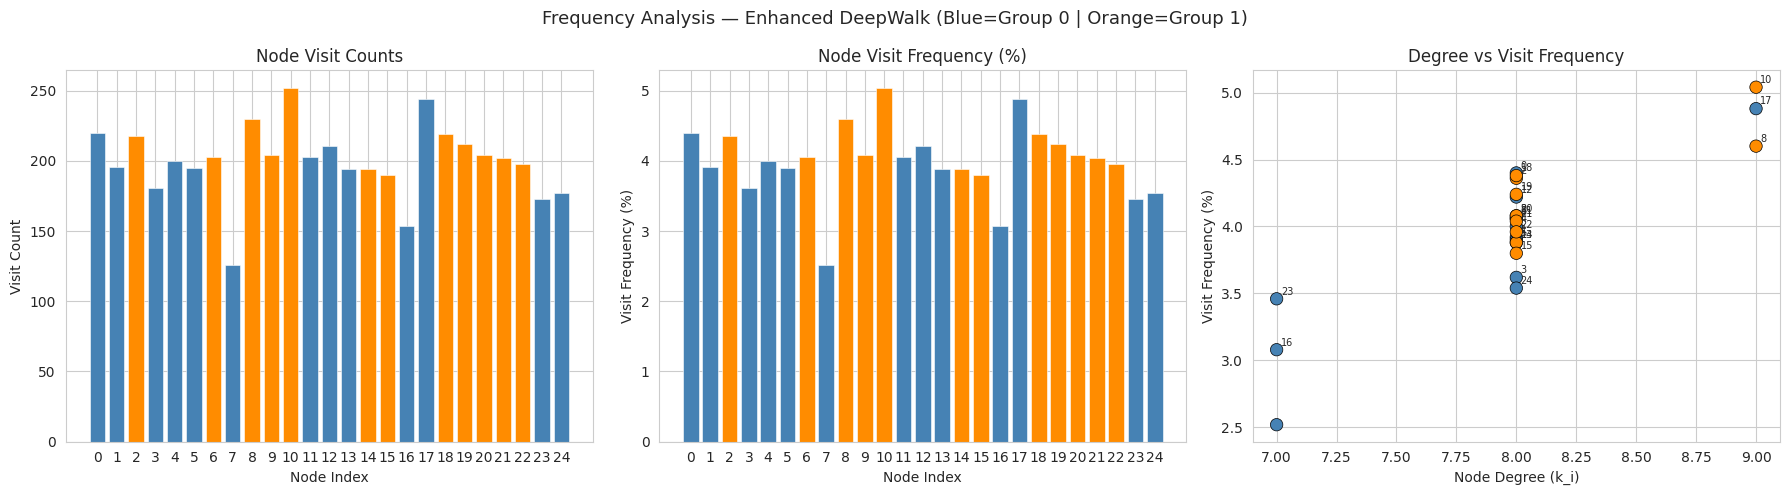

In [ ]:
# CELL: FREQUENCY ANALYSIS (Enhanced DeepWalk)
print("\n" + "=" * 60)
print("STEP 5: Frequency Analysis — Enhanced DeepWalk")
print("=" * 60)

all_visits = [int(node) for walk in enh_walks for node in walk]
counter = Counter(all_visits)
freq_dict = {i: counter.get(i, 0) for i in range(n)}
total = sum(freq_dict.values())

print(f"{'Node':>5}  {'Name':>12}  {'Degree':>7}  {'Visits':>8}  {'Freq %':>8}")
print("-" * 55)
for node, count in sorted(freq_dict.items(), key=lambda x: -x[1])[:20]:
    pct = count / total * 100
    name = name_map.get(node, str(node))
    deg = G.degree(node)
    print(f"{node:>5}  {name:>12}  {deg:>7}  {count:>8}  {pct:>7.2f}%")
print("-" * 55)
print(f"Total visits: {total}")

# Plot frequency
nodes_list = list(freq_dict.keys())
counts = [freq_dict[nd] for nd in nodes_list]
pcts = [c / total * 100 for c in counts]
degrees = [G.degree(nd) for nd in nodes_list]
colors = ['steelblue' if labels[nd] == 0 else 'darkorange' for nd in nodes_list]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Frequency Analysis — Enhanced DeepWalk (Blue=Group 0 | Orange=Group 1)", fontsize=13)

axes[0].bar(nodes_list, counts, color=colors, edgecolor='white', linewidth=0.4)
axes[0].set_xlabel("Node Index")
axes[0].set_ylabel("Visit Count")
axes[0].set_title("Node Visit Counts")
axes[0].set_xticks(nodes_list[::max(1, len(nodes_list)//15)])

axes[1].bar(nodes_list, pcts, color=colors, edgecolor='white', linewidth=0.4)
axes[1].set_xlabel("Node Index")
axes[1].set_ylabel("Visit Frequency (%)")
axes[1].set_title("Node Visit Frequency (%)")
axes[1].set_xticks(nodes_list[::max(1, len(nodes_list)//15)])

axes[2].scatter(degrees, pcts, c=colors, s=80, edgecolors='black', linewidth=0.5)
for nd, d, p in zip(nodes_list, degrees, pcts):
    if p > 3 or d > 8:
        axes[2].annotate(str(nd), (d, p), fontsize=7, xytext=(3, 3), textcoords='offset points')
axes[2].set_xlabel("Node Degree (k_i)")
axes[2].set_ylabel("Visit Frequency (%)")
axes[2].set_title("Degree vs Visit Frequency")

plt.tight_layout()
plt.show()

In [ ]:
# CELL: TRAIN EMBEDDINGS

print("\n" + "=" * 60)
print("STEP 6: Training Word2Vec Embeddings")
print("=" * 60)

EMBEDDING_DIM = 32
WINDOW = 5
EPOCHS = 10

enh_model = Word2Vec(sentences=enh_walks, vector_size=EMBEDDING_DIM, window=WINDOW,
                     min_count=0, workers=2, epochs=EPOCHS, sg=1)
n2v_model = Word2Vec(sentences=n2v_walks, vector_size=EMBEDDING_DIM, window=WINDOW,
                     min_count=0, workers=2, epochs=EPOCHS, sg=1)

print(f"Enhanced model: {len(enh_model.wv)} nodes, dim={EMBEDDING_DIM}")
print(f"Node2Vec model: {len(n2v_model.wv)} nodes, dim={EMBEDDING_DIM}")

# Extract matrices — safely handle any missing nodes
n_nodes = len(labels)
dim = EMBEDDING_DIM

X_enh = np.zeros((n_nodes, dim))
for i in range(n_nodes):
    if str(i) in enh_model.wv:
        X_enh[i] = enh_model.wv[str(i)]

X_n2v = np.zeros((n_nodes, dim))
for i in range(n_nodes):
    if str(i) in n2v_model.wv:
        X_n2v[i] = n2v_model.wv[str(i)]

print(f"X_enh shape: {X_enh.shape}")
print(f"X_n2v shape: {X_n2v.shape}")
print(f"labels shape: {labels.shape}")

# Show similar nodes for a few example nodes
key_nodes = [0, 1, 2, 3]
print("\n--- Most Similar Nodes (Enhanced DeepWalk) ---")
for node in key_nodes:
    name = name_map.get(node, str(node))
    similar = enh_model.wv.most_similar(str(node), topn=3)
    print(f"\nNode {node:>2} [{name}]:")
    for sim_node, score in similar:
        sim_name = name_map.get(int(sim_node), sim_node)
        print(f"  \u2192 Node {sim_node:>2} [{sim_name}]  similarity: {score:.4f}")


STEP 6: Training Word2Vec Embeddings
Enhanced model: 25 nodes, dim=32
Node2Vec model: 25 nodes, dim=32
X_enh shape: (25, 32)
X_n2v shape: (25, 32)
labels shape: (25,)

--- Most Similar Nodes (Enhanced DeepWalk) ---

Node  0 [Akron]:
  → Node 12 [Marshall]  similarity: 0.9974
  → Node 13 [MiamiOhio]  similarity: 0.9970
  → Node 24 [WesternMichigan]  similarity: 0.9966

Node  1 [BallState]:
  → Node 17 [Ohio]  similarity: 0.9912
  → Node  7 [EasternMichigan]  similarity: 0.9848
  → Node  5 [CentralMichigan]  similarity: 0.9846

Node  2 [Baylor]:
  → Node 19 [OklahomaState]  similarity: 0.9977
  → Node  6 [Colorado]  similarity: 0.9974
  → Node 15 [Nebraska]  similarity: 0.9973

Node  3 [BowlingGreenState]:
  → Node  7 [EasternMichigan]  similarity: 0.9972
  → Node 11 [Kent]  similarity: 0.9962
  → Node  5 [CentralMichigan]  similarity: 0.9959


In [ ]:
# CELL: 5-FOLD CROSS-VALIDATION

print("\n" + "=" * 60)
print("STEP 7: 5-Fold Cross-Validation (Logistic Regression)")
print("=" * 60)

clf = LogisticRegression(max_iter=1000)
skf = StratifiedKFold(5, shuffle=True, random_state=42)

acc_enh = cross_val_score(clf, X_enh, labels, cv=skf, scoring='accuracy')
f1_enh = cross_val_score(clf, X_enh, labels, cv=skf, scoring='f1_weighted')
acc_n2v = cross_val_score(clf, X_n2v, labels, cv=skf, scoring='accuracy')
f1_n2v = cross_val_score(clf, X_n2v, labels, cv=skf, scoring='f1_weighted')

print(f"{'Method':<20} {'Mean Acc':>10} {'Std Acc':>10} {'Mean F1':>10} {'Std F1':>10}")
print("-" * 65)
print(f"{'Enhanced DeepWalk':<20} {acc_enh.mean():>10.3f} {acc_enh.std():>10.3f} {f1_enh.mean():>10.3f} {f1_enh.std():>10.3f}")
print(f"{'Node2Vec':<20} {acc_n2v.mean():>10.3f} {acc_n2v.std():>10.3f} {f1_n2v.mean():>10.3f} {f1_n2v.std():>10.3f}")


STEP 7: 5-Fold Cross-Validation (Logistic Regression)
Method                 Mean Acc    Std Acc    Mean F1     Std F1
-----------------------------------------------------------------
Enhanced DeepWalk         1.000      0.000      1.000      0.000
Node2Vec                  1.000      0.000      1.000      0.000


In [ ]:
# CELL: SINGLE TRAIN/TEST SPLIT CLASSIFICATION

print("\n" + "=" * 60)
print("STEP 8: Single Train/Test Split Classification")
print("=" * 60)

TEST_SIZE = 0.3
RANDOM_STATE = 42

# Same split for both methods
indices = np.arange(len(labels))
_, _, _, _, idx_train, idx_test = train_test_split(
    X_enh, labels, indices, test_size=TEST_SIZE,
    random_state=RANDOM_STATE, stratify=labels
)

classifiers = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'SVM': SVC(kernel='rbf', random_state=RANDOM_STATE)
}

enh_results = {}
n2v_results = {}

for clf_name, clf in classifiers.items():
    # Enhanced
    clf.fit(X_enh[idx_train], labels[idx_train])
    y_pred_enh = clf.predict(X_enh[idx_test])
    enh_results[clf_name] = {
        'accuracy': accuracy_score(labels[idx_test], y_pred_enh),
        'f1': f1_score(labels[idx_test], y_pred_enh, average='weighted'),
        'y_test': labels[idx_test],
        'y_pred': y_pred_enh,
        'cm': confusion_matrix(labels[idx_test], y_pred_enh)
    }
    # Node2Vec (re-instantiate classifier)
    clf2 = type(clf)(**clf.get_params())
    clf2.fit(X_n2v[idx_train], labels[idx_train])
    y_pred_n2v = clf2.predict(X_n2v[idx_test])
    n2v_results[clf_name] = {
        'accuracy': accuracy_score(labels[idx_test], y_pred_n2v),
        'f1': f1_score(labels[idx_test], y_pred_n2v, average='weighted'),
        'y_test': labels[idx_test],
        'y_pred': y_pred_n2v,
        'cm': confusion_matrix(labels[idx_test], y_pred_n2v)
    }

print(f"{'Classifier':<20} {'Enhanced Acc':>12} {'Enhanced F1':>12} {'Node2Vec Acc':>12} {'Node2Vec F1':>12}")
print("-" * 75)
for clf_name in classifiers:
    print(f"{clf_name:<20} {enh_results[clf_name]['accuracy']:>12.3f} {enh_results[clf_name]['f1']:>12.3f} "
          f"{n2v_results[clf_name]['accuracy']:>12.3f} {n2v_results[clf_name]['f1']:>12.3f}")


STEP 8: Single Train/Test Split Classification
Classifier           Enhanced Acc  Enhanced F1 Node2Vec Acc  Node2Vec F1
---------------------------------------------------------------------------
LogisticRegression          1.000        1.000        1.000        1.000
RandomForest                1.000        1.000        1.000        1.000
SVM                         1.000        1.000        1.000        1.000


In [ ]:
# CELL: NODE CLASSIFICATION CHANGES
print("\n" + "=" * 60)
print("STEP 9: Node Classification Changes")
print("=" * 60)

CLF = 'LogisticRegression'
y_true = enh_results[CLF]['y_test']
y_pred_enh = enh_results[CLF]['y_pred']
y_pred_n2v = n2v_results[CLF]['y_pred']

changes = []
for i in range(len(y_true)):
    if y_pred_enh[i] != y_pred_n2v[i]:
        changes.append({
            'node_id': int(idx_test[i]),
            'true_label': f"Group {y_true[i]}",
            'enhanced': f"Group {y_pred_enh[i]}",
            'node2vec': f"Group {y_pred_n2v[i]}",
            'improved': (y_pred_n2v[i] == y_true[i]) and (y_pred_enh[i] != y_true[i])
        })

if changes:
    print(f"Found {len(changes)} node(s) with changed predictions:")
    print(f"{'Node':>6} {'True':>10} {'Enhanced':>10} {'Node2Vec':>10} {'Fixed?':>8}")
    print("-" * 55)
    for c in changes:
        fixed = "YES" if c['improved'] else "NO"
        print(f"{c['node_id']:>6} {c['true_label']:>10} {c['enhanced']:>10} {c['node2vec']:>10} {fixed:>8}")
else:
    print("No prediction changes between Enhanced DeepWalk and Node2Vec.")


STEP 9: Node Classification Changes
No prediction changes between Enhanced DeepWalk and Node2Vec.



STEP 10: Plot — Accuracy & F1 Comparison

--- Accuracy & F1 Comparison ---
Classifier           Method                 Accuracy         F1
--------------------------------------------------------------
LogisticRegression   Enhanced DeepWalk        1.0000     1.0000
LogisticRegression   Node2Vec                 1.0000     1.0000
RandomForest         Enhanced DeepWalk        1.0000     1.0000
RandomForest         Node2Vec                 1.0000     1.0000
SVM                  Enhanced DeepWalk        1.0000     1.0000
SVM                  Node2Vec                 1.0000     1.0000


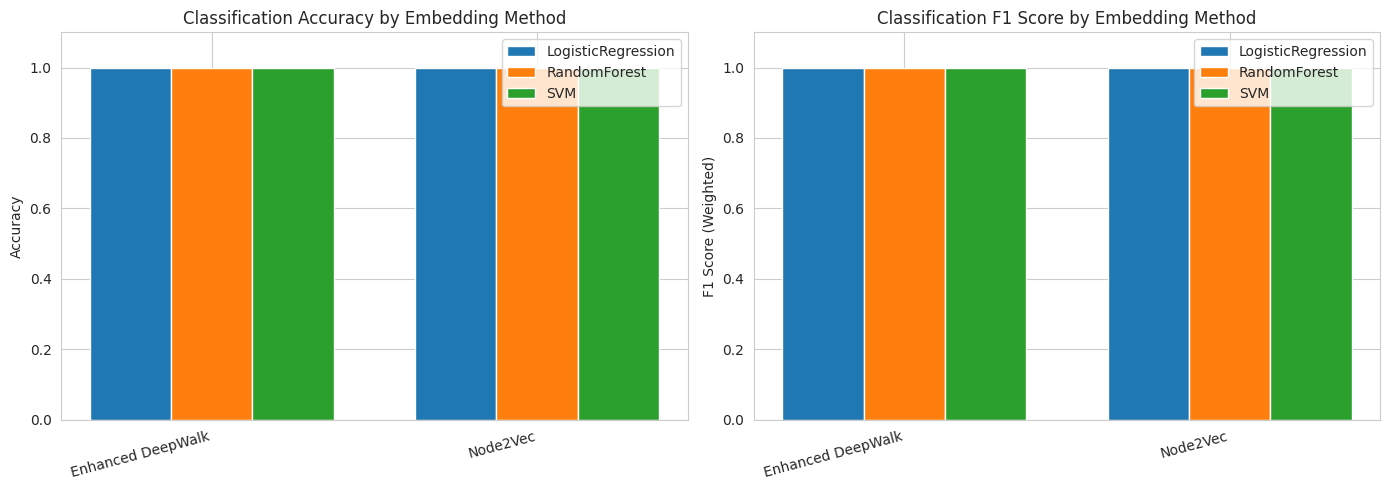

In [ ]:
# CELL: PLOT ACCURACY COMPARISON

print("\n" + "=" * 60)
print("STEP 10: Plot — Accuracy & F1 Comparison")
print("=" * 60)

methods = ['Enhanced DeepWalk', 'Node2Vec']
clf_names = list(classifiers.keys())
x = np.arange(len(methods))
width = 0.25

print("\n--- Accuracy & F1 Comparison ---")
print(f"{'Classifier':<20} {'Method':<20} {'Accuracy':>10} {'F1':>10}")
print("-" * 62)
for clf_name in clf_names:
    print(f"{clf_name:<20} {'Enhanced DeepWalk':<20} {enh_results[clf_name]['accuracy']:>10.4f} {enh_results[clf_name]['f1']:>10.4f}")
    print(f"{clf_name:<20} {'Node2Vec':<20} {n2v_results[clf_name]['accuracy']:>10.4f} {n2v_results[clf_name]['f1']:>10.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, clf_name in enumerate(clf_names):
    accs = [enh_results[clf_name]['accuracy'], n2v_results[clf_name]['accuracy']]
    axes[0].bar(x + i*width, accs, width, label=clf_name)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Classification Accuracy by Embedding Method')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(methods, rotation=15, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 1.1)

for i, clf_name in enumerate(clf_names):
    f1s = [enh_results[clf_name]['f1'], n2v_results[clf_name]['f1']]
    axes[1].bar(x + i*width, f1s, width, label=clf_name)
axes[1].set_ylabel('F1 Score (Weighted)')
axes[1].set_title('Classification F1 Score by Embedding Method')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(methods, rotation=15, ha='right')
axes[1].legend()
axes[1].set_ylim(0, 1.1)
plt.tight_layout()
plt.show()


STEP 11: Plot — Confusion Matrices


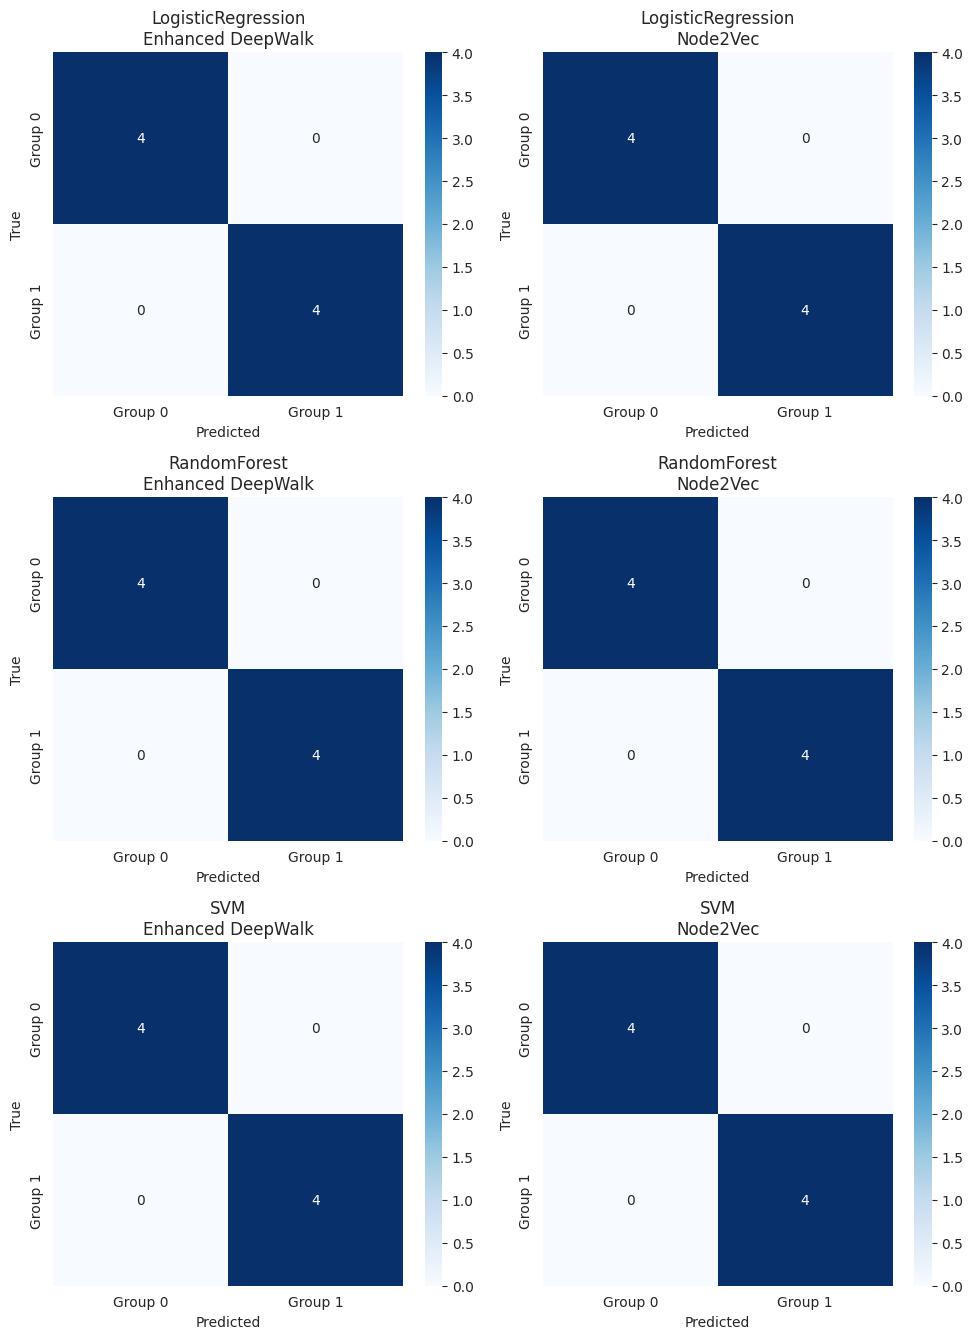

In [ ]:
# CELL: PLOT CONFUSION MATRICES
# Confusion matrices comparing 3 classifiers (LogisticRegression, RandomForest, SVM)
# across 2 embedding methods (Enhanced DeepWalk, Node2Vec) on the loaded
# dataset's 2-group node classification task.

print("\n" + "=" * 60)
print("STEP 11: Plot — Confusion Matrices")
print("=" * 60)

fig, axes = plt.subplots(len(clf_names), 2, figsize=(10, 4.5*len(clf_names)))
if len(clf_names) == 1:
    axes = axes.reshape(1, -1)

for i, clf_name in enumerate(clf_names):
    for j, (method, results) in enumerate([('Enhanced DeepWalk', enh_results), ('Node2Vec', n2v_results)]):
        cm = results[clf_name]['cm']
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i, j],
                   xticklabels=['Group 0', 'Group 1'],
                   yticklabels=['Group 0', 'Group 1'])
        axes[i, j].set_title(f'{clf_name}\n{method}')
        axes[i, j].set_xlabel('Predicted')
        axes[i, j].set_ylabel('True')
plt.tight_layout()
plt.show()


STEP 12: Plot — Embeddings 2D Projection (PCA)


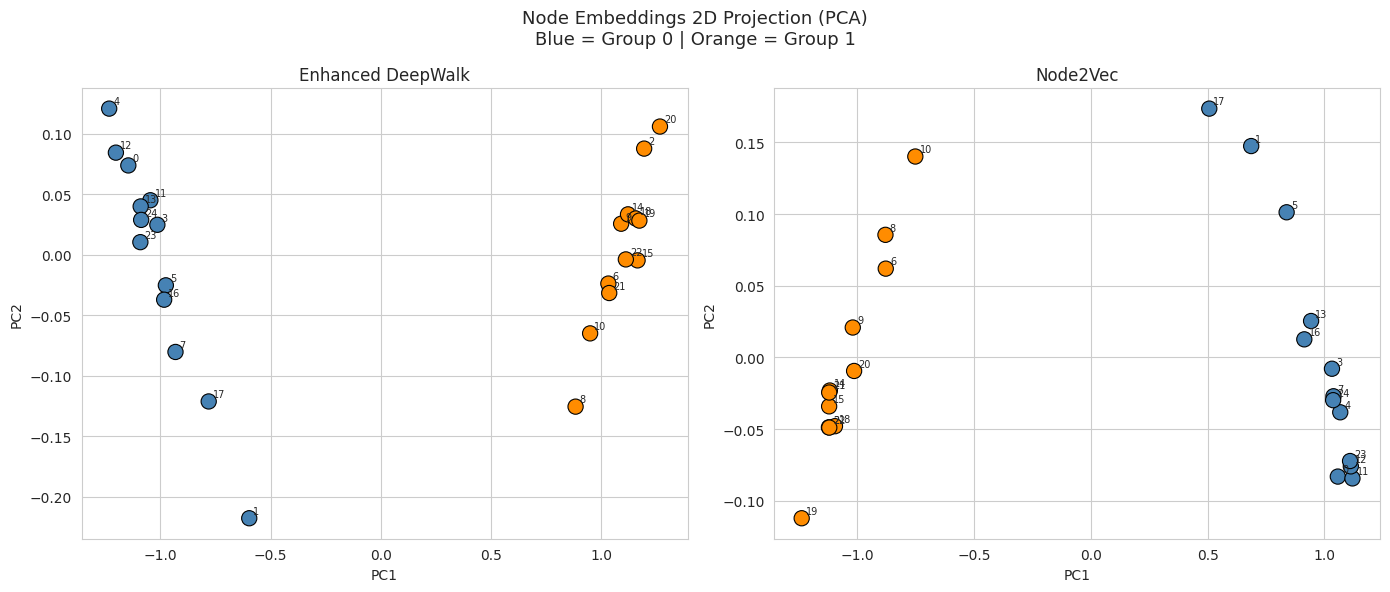

In [ ]:
# CELL: PLOT EMBEDDINGS PCA
print("\n" + "=" * 60)
print("STEP 12: Plot — Embeddings 2D Projection (PCA)")
print("=" * 60)

pca = PCA(n_components=2)
colors = ['steelblue' if labels[i] == 0 else 'darkorange' for i in range(len(labels))]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Node Embeddings 2D Projection (PCA)\nBlue = Group 0 | Orange = Group 1', fontsize=13)

for ax, (name, X) in zip(axes, [('Enhanced DeepWalk', X_enh), ('Node2Vec', X_n2v)]):
    emb_2d = pca.fit_transform(X)
    ax.scatter(emb_2d[:, 0], emb_2d[:, 1], c=colors, s=120, edgecolors='black', linewidth=0.8)
    for i, (x, y) in enumerate(emb_2d):
        ax.annotate(str(i), (x, y), fontsize=7, xytext=(3, 3), textcoords='offset points')
    ax.set_title(name)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.show()